In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
data = pd.read_csv('data/House_Price_Dataset.csv')
testData = pd.read_csv('data/Test_Data_For_Prediction.csv')

In [48]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       50 non-null     int64  
 1   square_footage           50 non-null     int64  
 2   bedrooms                 50 non-null     int64  
 3   bathrooms                50 non-null     float64
 4   year_built               50 non-null     int64  
 5   lot_size                 50 non-null     int64  
 6   distance_to_city_center  50 non-null     float64
 7   school_rating            50 non-null     float64
 8   price                    50 non-null     int64  
dtypes: float64(3), int64(6)
memory usage: 3.6 KB


In [49]:
x_train = data.drop(columns=['id', 'price'])
y_train = data['price']

In [50]:
trainData = x_train.join(y_train)
trainData["bedrooms"] = np.log(trainData["bedrooms"] + 1)
trainData["bathrooms"] = np.log(trainData["bathrooms"] + 1)
# trainData.hist(figsize=(15, 8))

<Axes: >

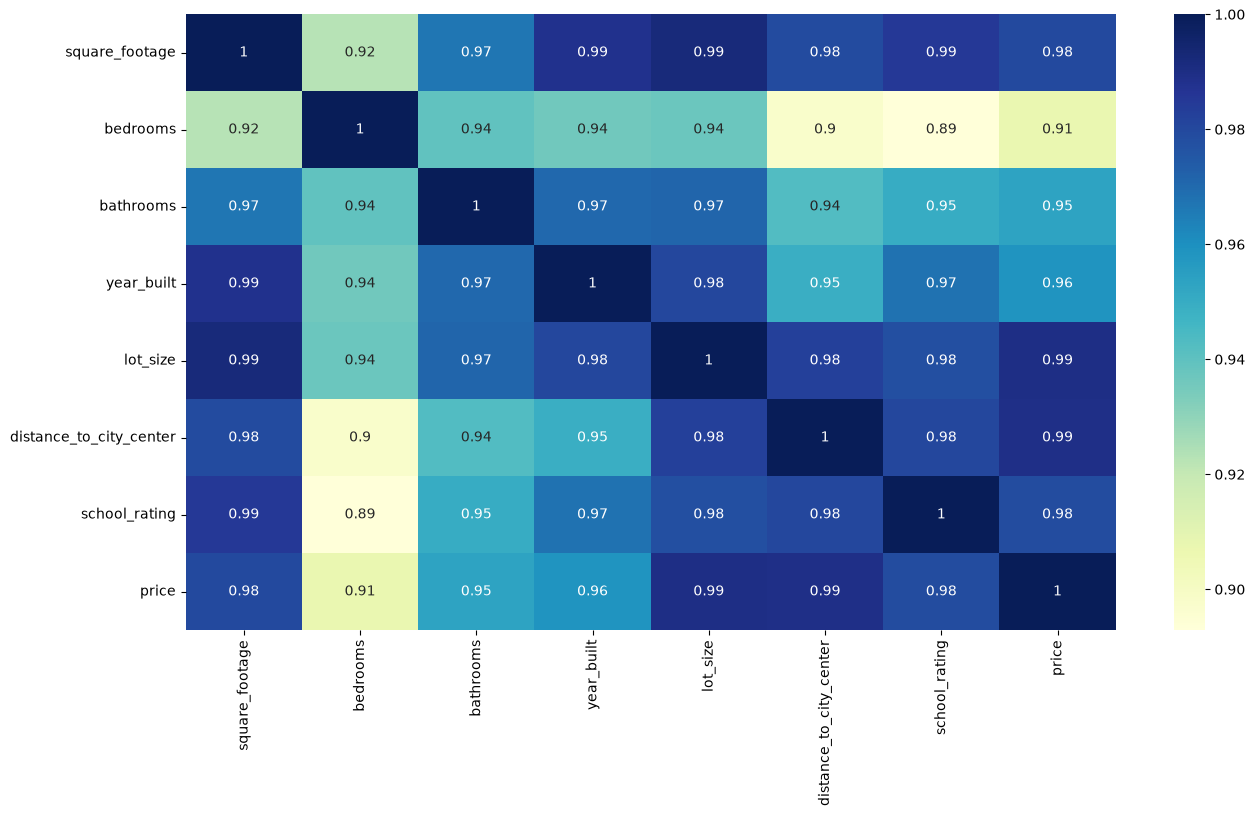

In [51]:
plt.figure(figsize=(15, 8))
sns.heatmap(trainData.corr(numeric_only=True), annot=True, cmap='YlGnBu')

<Axes: xlabel='bedrooms', ylabel='bathrooms'>

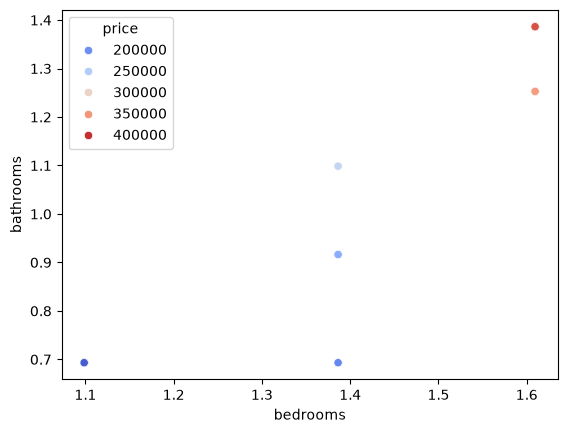

In [52]:
sns.scatterplot(x="bedrooms", y="bathrooms", data=trainData, hue="price", palette="coolwarm")

In [53]:
# trainData["bedroom_ratio"] = trainData["bedrooms"] / (trainData["bathrooms"] + trainData["bedrooms"])
# plt.figure(figsize=(15, 8))
# sns.heatmap(trainData.corr(numeric_only=True), annot=True, cmap='YlGnBu')

In [54]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
x_train, y_train = trainData.drop(columns=['price']), trainData['price']
reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ -110.46,-39778.32, -2101.08,..., 42.69, 16480.3 , 20688.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['square_footage','bedrooms','bathrooms',...,'lot_size', 'distance_to_city_center','school_rating']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.152e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [55]:
# testData["bedroom_ratio"] = testData["bedrooms"] / (testData["bathrooms"] + testData["bedrooms"])
testData["bedrooms"] = np.log(testData["bedrooms"] + 1)
testData["bathrooms"] = np.log(testData["bathrooms"] + 1)

In [56]:
reg.predict(testData.drop(columns=[]))

array([249107.65353639, 366397.37871911, 176342.24020162, 300181.88131784,
       211766.33978614, 412499.37016425, 257770.39747837, 150081.00030883,
       351259.62340938, 191177.306373  ])